# X-VLA WidowX Trajectory Visualization

Run X-VLA inference on a simulated WidowX 250s robot in MuJoCo.
The model predicts end-effector trajectories for a specified task,
visualized as colored dots in the camera views.

**Requirements:** GPU runtime recommended (T4 is sufficient), but CPU is fine for this.

In [ ]:
import os

# If assets/ exists locally, we're already in the repo root — skip cloning
if not os.path.exists('assets'):
    print("Assuming Colab")
    %cd /content
    !git clone --depth 1 https://github.com/avikde/vla-pipeline.git || echo "Already cloned"
    %cd vla-pipeline

    # Install dependencies
    %pip install -q "lerobot[xvla]" mujoco Pillow
    # NOTE: Do this if lerobot insists on installing torch 2.7.1+cpu
    # %pip uninstall torch torchvision -y && pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Assuming Colab
/content
Cloning into 'vla-pipeline'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 53 (delta 3), reused 34 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 5.64 MiB | 7.59 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/vla-pipeline


In [ ]:
import sys

# Use EGL for headless OpenGL rendering (Colab/Linux servers without display)
# Skip on Windows/macOS where native windowing is available
if sys.platform == 'linux' and 'DISPLAY' not in os.environ:
    os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import numpy as np
import torch
import matplotlib.pyplot as plt

print(f"MuJoCo: {mujoco.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
# print(f"MUJOCO_GL: {os.environ.get('MUJOCO_GL', 'default')}")

MuJoCo: 3.5.0
PyTorch: 2.10.0+cu128
CUDA available: True


### 1. Load X-VLA Policy (will take some time to download ~4GB the first time)

In [ ]:
from lerobot.policies.xvla.modeling_xvla import XVLAPolicy
from transformers import AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
policy = XVLAPolicy.from_pretrained("lerobot/xvla-widowx").to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(policy.config.tokenizer_name)

print(f"Device: {device}")
print(f"Action mode: {policy.config.action_mode}")
print(f"Chunk size: {policy.config.chunk_size}")
print(f"N action steps: {policy.config.n_action_steps}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

Florence2ForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


model.safetensors:   0%|          | 0.00/3.52G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda
Action mode: ee6d
Chunk size: 30
N action steps: 30


### 2. Load MuJoCo Scene

In [ ]:
xml_path = 'assets/widowx/widowx_vision_scene.xml'
mj_model = mujoco.MjModel.from_xml_path(xml_path)
mj_data = mujoco.MjData(mj_model)

# Initialize to home pose (avoids finger collision at qpos=0)
home_qpos = mj_model.keyframe('home').qpos
n_robot_joints = 8  # 6 arm + 2 finger
mj_data.qpos[:n_robot_joints] = home_qpos[:n_robot_joints]
mj_data.ctrl[:] = mj_model.keyframe('home').ctrl
mujoco.mj_forward(mj_model, mj_data)

# Settle physics
for _ in range(100):
    mujoco.mj_step(mj_model, mj_data)

print(f"Model loaded: nq={mj_model.nq}, nv={mj_model.nv}, nu={mj_model.nu}")

Model loaded: nq=15, nv=14, nu=7


### 3. Helper Functions

In [ ]:
VLA_WIDTH, VLA_HEIGHT = 256, 256
mj_model.vis.global_.offwidth = max(mj_model.vis.global_.offwidth, VLA_WIDTH)
mj_model.vis.global_.offheight = max(mj_model.vis.global_.offheight, VLA_HEIGHT)
renderer = mujoco.Renderer(mj_model, height=VLA_HEIGHT, width=VLA_WIDTH)

# Trajectory marker colors (green -> red gradient)
NUM_MARKERS = 10
MARKER_COLORS = []
for i in range(NUM_MARKERS):
    fade = i / max(1, NUM_MARKERS - 1)
    MARKER_COLORS.append(np.array([fade, 1.0 - fade, 0.0, 0.6], dtype=np.float32))


def render_camera(camera_name, trajectory=None):
    """Render from a camera, optionally with trajectory spheres."""
    camera_id = mj_model.camera(camera_name).id
    renderer.update_scene(mj_data, camera=camera_id)
    if trajectory:
        for i, target_xyz in enumerate(trajectory):
            mujoco.mjv_initGeom(
                renderer.scene.geoms[renderer.scene.ngeom],
                type=mujoco.mjtGeom.mjGEOM_SPHERE,
                size=[0.005, 0, 0],
                pos=target_xyz.astype(np.float64),
                mat=np.eye(3).flatten(),
                rgba=MARKER_COLORS[i],
            )
            renderer.scene.ngeom += 1
    return renderer.render()


def preprocess_image(rgb_image, device='cpu'):
    img_tensor = torch.from_numpy(rgb_image).permute(2, 0, 1).float() / 255.0
    return img_tensor.unsqueeze(0).to(device)


def get_ee_pose():
    ee_body_id = mj_model.body("wx250s/gripper_link").id
    return mj_data.xpos[ee_body_id].copy(), mj_data.xmat[ee_body_id].reshape(3, 3).copy()


def rotation_matrix_to_euler(rot_mat):
    sy = np.sqrt(rot_mat[0, 0]**2 + rot_mat[1, 0]**2)
    if sy > 1e-6:
        roll = np.arctan2(rot_mat[2, 1], rot_mat[2, 2])
        pitch = np.arctan2(-rot_mat[2, 0], sy)
        yaw = np.arctan2(rot_mat[1, 0], rot_mat[0, 0])
    else:
        roll = np.arctan2(-rot_mat[1, 2], rot_mat[1, 1])
        pitch = np.arctan2(-rot_mat[2, 0], sy)
        yaw = 0.0
    return roll, pitch, yaw


def get_ee_state_8d():
    """8D EE state matching BridgeData: [x, y, z, roll, pitch, yaw, pad, gripper]"""
    ee_pos, ee_rot = get_ee_pose()
    roll, pitch, yaw = rotation_matrix_to_euler(ee_rot)
    gripper_pos = mj_data.qpos[mj_model.joint("left_finger").id]
    return np.array([ee_pos[0], ee_pos[1], ee_pos[2],
                     roll, pitch, yaw, 0.0, gripper_pos], dtype=np.float32)


def get_cube_position(cube_name="red_block"):
    try:
        return mj_data.xpos[mj_model.body(cube_name).id].copy()
    except Exception:
        return None


print("Helpers ready.")

Helpers ready.


### 4. Run Inference

**Specify the task below 👇**

In [ ]:
task_instruction = "Move the robot arm to its highest vertical position" # 👈 Edit here

tokenized = tokenizer(
    task_instruction,
    padding='max_length',
    max_length=policy.config.tokenizer_max_length,
    truncation=True,
    return_tensors='pt'
)
language_tokens = tokenized['input_ids'].to(device)
language_attention_mask = tokenized['attention_mask'].to(device)

# Initial state
ee_pos, _ = get_ee_pose()
cube_pos = get_cube_position()
print(f"Task: '{task_instruction}'")
print(f"EE position: {ee_pos}")
print(f"Cube position: {cube_pos}")
print(f"Distance: {np.linalg.norm(ee_pos - cube_pos):.3f}m")

Task: 'Move the robot arm to its highest vertical position'
EE position: [ 1.58816596e-01 -1.21958531e-06  2.28693613e-01]
Cube position: [0.25       0.1        0.01989198]
Distance: 0.249m


In [ ]:
# Run inference until we get the first action chunk
cached_action_targets = []
step = 0

while len(cached_action_targets) == 0:
    img = render_camera('up')
    img2 = render_camera('side')

    img_tensor = preprocess_image(img, device=device)
    img2_tensor = preprocess_image(img2, device=device)
    ee_state_8d = get_ee_state_8d()

    observation = {
        'observation.images.image': img_tensor,
        'observation.images.image2': img2_tensor,
        'observation.state': torch.from_numpy(ee_state_8d).float().unsqueeze(0).to(device),
        'observation.language.tokens': language_tokens,
        'observation.language.attention_mask': language_attention_mask,
    }

    with torch.inference_mode():
        actions = policy.select_action(observation)

    # Check if a new chunk was generated
    action_queue = policy._queues.get("action", [])
    queue_size = len(action_queue)
    is_new_chunk = queue_size == policy.config.chunk_size - 1

    if is_new_chunk:
        for queued_action in list(action_queue)[:NUM_MARKERS]:
            if isinstance(queued_action, torch.Tensor):
                cached_action_targets.append(queued_action.flatten()[:3].cpu().numpy())
            else:
                cached_action_targets.append(np.array(queued_action).flatten()[:3])

    mujoco.mj_step(mj_model, mj_data)
    step += 1
    print(f"Step {step}, queue: {queue_size}", end='\r')

actions_np = actions.detach().cpu().numpy().flatten()
print(f"\nFirst chunk generated at step {step}")
print(f"Cached {len(cached_action_targets)} trajectory targets")
print(f"Action vector (20D): {np.array2string(actions_np, precision=4, suppress_small=True)}")

Step 1, queue: 29
First chunk generated at step 1
Cached 10 trajectory targets
Action vector (20D): [ 0.1559 -0.0032  0.2374  0.0354  0.9653 -0.9503  0.0347  0.025  -0.0771
  0.34   -0.0004 -0.      0.0001 -0.0004  0.0005 -0.0002 -0.0007  0.0002
 -0.0004  0.    ]


### 5. VLM Attention

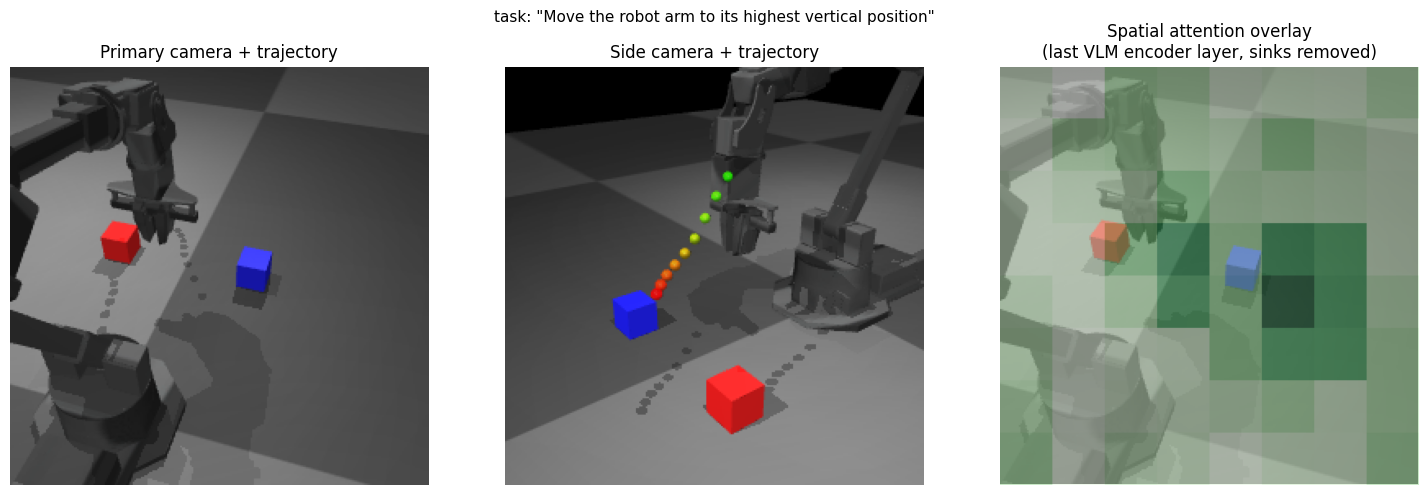

Token sequence: 65 image patches + 50 language tokens = 115 total

Top-10 most-attended tokens:
   1. [ 65] '<s>'                 weight=0.35313 <- sink
   2. [ 67] 'Ġthe'                weight=0.06784
   3. [ 71] 'Ġits'                weight=0.05395
   4. [ 72] 'Ġhighest'            weight=0.03894
   5. [ 75] '</s>'                weight=0.02149 <- sink
   6. [ 69] 'Ġarm'                weight=0.01591
   7. [ 37] 'img37'               weight=0.01431
   8. [ 68] 'Ġrobot'              weight=0.01324
   9. [ 27] 'img27'               weight=0.01211
  10. [ 29] 'img29'               weight=0.01134


In [ ]:
# Render trajectory views (with colored dots) for use in the visualization below
snap_up   = render_camera('up',   trajectory=cached_action_targets)
snap_side = render_camera('side', trajectory=cached_action_targets)

with torch.inference_mode():
    # Stack both camera images: [1, 2, C, H, W]
    image_input = torch.cat([img_tensor.unsqueeze(1), img2_tensor.unsqueeze(1)], dim=1)

    # Encode images (same flattening as forward_vlm)
    flat_imgs = image_input.flatten(0, 1)                    # [2, C, H, W]
    valid_feats = policy.model.vlm._encode_image(flat_imgs)  # [2, P, D]
    P = valid_feats.shape[1]
    image_features = valid_feats.view(1, 2, P, -1)           # [1, 2, P, D]

    # Language embeddings
    inputs_embeds = policy.model.vlm.get_input_embeddings()(language_tokens)  # [1, L, D]

    # Merge primary image (cam 0) + language → [1, P+L, D]
    merged_embeds, attn_mask = policy.model.vlm._merge_input_ids_with_image_features(
        image_features[:, 0], inputs_embeds
    )

    # BART encoder with attention weights enabled
    encoder = policy.model.vlm.language_model.model.encoder
    enc_out = encoder(
        attention_mask=attn_mask,
        inputs_embeds=merged_embeds,
        output_attentions=True,
    )

# Last-layer attention: average over heads → [S, S]
last_attn = enc_out.attentions[-1][0].cpu().float()  # [H, S, S]
attn_avg  = last_attn.mean(dim=0).numpy()            # [S, S]

n_lang = inputs_embeds.shape[1]
n_img  = attn_avg.shape[0] - n_lang
S      = attn_avg.shape[0]

# Token labels
lang_strs  = tokenizer.convert_ids_to_tokens(language_tokens[0].cpu().tolist())
tok_labels = [f"img{i}" for i in range(n_img)] + lang_strs

# ── Spatial overlay (attention sinks removed) ──────────────────────────────────
# DaViT produces 64 spatial patches (8×8 grid) + 1 globally-pooled token = 65.
N_SPATIAL = 64
GRID      = int(N_SPATIAL ** 0.5)   # 8
PATCH_PX  = VLA_WIDTH // GRID       # 32 px per patch side

sink_ids     = {tokenizer.bos_token_id, tokenizer.eos_token_id}
lang_id_list = language_tokens[0].cpu().tolist()
sink_indices = {n_img + i for i, tid in enumerate(lang_id_list) if tid in sink_ids}

non_sink         = [i for i in range(S) if i not in sink_indices]
attn_no_sink     = attn_avg[np.ix_(non_sink, non_sink)]
img_cols_reduced = [non_sink.index(i) for i in range(N_SPATIAL) if i in non_sink]
spatial_attn     = attn_no_sink[:, img_cols_reduced].mean(0)   # [N_SPATIAL]
spatial_grid     = spatial_attn.reshape(GRID, GRID)             # [8, 8]

heatmap = np.kron(spatial_grid, np.ones((PATCH_PX, PATCH_PX)))  # [256, 256]
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# ── 3-panel visualization ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(snap_up)
axes[0].set_title("Primary camera + trajectory")
axes[0].axis('off')

axes[1].imshow(snap_side)
axes[1].set_title("Side camera + trajectory")
axes[1].axis('off')

axes[2].imshow(img)
axes[2].imshow(heatmap, cmap='Greens', alpha=0.5, extent=[0, VLA_WIDTH, VLA_HEIGHT, 0])
axes[2].set_title("Spatial attention overlay\n(last VLM encoder layer, sinks removed)")
axes[2].axis('off')

plt.suptitle(f'task: "{task_instruction}"', fontsize=11)
plt.tight_layout()
plt.show()

# Top-10 tokens
attn_received = attn_avg.mean(0)
top10 = attn_received.argsort()[::-1][:10]
print(f"Token sequence: {n_img} image patches + {n_lang} language tokens = {S} total")
print(f"\nTop-10 most-attended tokens:")
for rank, idx in enumerate(top10):
    label = tok_labels[idx] if idx < len(tok_labels) else f"tok{idx}"
    sink_marker = " <- sink" if idx in sink_indices else ""
    print(f"  {rank+1:2d}. [{idx:3d}] {label!r:<20s}  weight={attn_received[idx]:.5f}{sink_marker}")